# Proteoform inference: reproducing Bludau et al. (2021)

This tutorial reproduces the tissue-specific proteoform analysis from the mouse SWATH-MS dataset presented in:

> Bludau I, Frank M, Dörig C, Cai Y, Heusel M, Rosenberger G, Picotti P, Collins BC, Röst H, and Aebersold R. **Systematic detection of functional proteoform groups from bottom-up proteomic datasets.** *Nature Communications*, 12:3810, 2021. [doi:10.1038/s41467-021-24030-x](https://doi.org/10.1038/s41467-021-24030-x)

The authors introduced COPF (COrrelation-based functional ProteoForm assessment), a data-driven strategy that assigns peptides to co-varying proteoform groups based on peptide correlation patterns. Applied to SWATH-MS data from five mouse tissues (brain, brown adipose tissue, heart, liver, and quadriceps) across eight BXD mice, COPF identified 63 proteins with functional proteoform groups, of which 56 (89%) were tissue-specific.

Here, we reproduce the core proteoform inference workflow and selected results (Figures 6B, 7A, 7C, 7D, 7F) using ProteoPy.

## Setup

In [1]:
# Jupyter autoreload for development
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt

import proteopy as pr  # Convention: import proteopy as pr
from proteopy.utils import is_proteodata

random.seed(42)

cwd = Path('.').resolve()
root = cwd.parents[1]
os.chdir(root)

/home/ifichtner/miniforge3/envs/proteopy-usage2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reading in the data

The dataset consists of peptide-level SWATH-MS intensities from five tissues of eight BXD mice. We parse tissue and mouse identifiers from the sample names and remove the iRT spike-in protein.

In [3]:
adata = pr.read.long(
    intensities="data/bludau-2021_mouse-tissue_intensities.txt",
    level="peptide",
    sep="\t",
    sample_annotation="data/bludau-2021_mouse-tissue_fraction_annotation.txt",
    column_map={"sample_id": "filename"},
    fill_na=0,
    )

# Parse `tissue` and `mouse` from `sample_id`
parts = adata.obs['sample_id'].str.split('_', n=1, expand=True)
parts.columns = ['p1', 'p2']
tissue_first = parts['p1'].str.fullmatch(r'[Brain|BAT|Heart|Liver|Quad]+').copy()
adata.obs['tissue'] = np.where(tissue_first, parts['p1'], parts['p2']).copy()
adata.obs['mouse']  = np.where(tissue_first, parts['p2'], parts['p1']).copy()

# Remove iRT spike-in protein
protein_excl = ['iRT_protein']
mask = ~adata.var['protein_id'].isin(protein_excl)
adata = adata[:, mask].copy()

print("Is proteodata: ", is_proteodata(adata))
adata

Is proteodata:  (True, 'peptide')


AnnData object with n_obs × n_vars = 40 × 32679
    obs: 'sample_id', 'fraction_number', 'tissue', 'mouse'
    var: 'peptide_id', 'protein_id'

In [4]:
adata.obs.head(n=10)

,sample_id,fraction_number,tissue,mouse
101_Brain,101_Brain,8,Brain,101
45_Brain,45_Brain,3,Brain,45
66_Brain,66_Brain,4,Brain,66
68_Brain,68_Brain,5,Brain,68
73_Brain,73_Brain,6,Brain,73
80_Brain,80_Brain,7,Brain,80
BAT_101,BAT_101,16,BAT,101
BAT_45,BAT_45,11,BAT,45
BAT_66,BAT_66,12,BAT,66
BAT_68,BAT_68,13,BAT,68


In [5]:
adata.var.head(n=10)

,peptide_id,protein_id
AAAAAAAAAAAAAAAGAAGK,AAAAAAAAAAAAAAAGAAGK,P55012
AAAAADLANR,AAAAADLANR,Q9JHS4
AAAADGEPLHNEEER,AAAADGEPLHNEEER,Q80WW9
AAAAEGARPLER,AAAAEGARPLER,Q80UM7
AAAAKEEAPK,AAAAKEEAPK,Q91XV3
AAAANLC(UniMod:4)PGDVILAIDGFGTESMTHADAQDR,AAAANLC(UniMod:4)PGDVILAIDGFGTESMTHADAQDR,O70209
AAAAYALGR,AAAAYALGR,Q6ZQ73
AAADLM(UniMod:35)AYC(UniMod:4)EAHAKEDPLLTPVPASENPFR,AAADLM(UniMod:35)AYC(UniMod:4)EAHAKEDPLLTPVPAS...,P63213
AAADLMAYC(UniMod:4)EAHAK,AAADLMAYC(UniMod:4)EAHAK,P63213
AAADLMAYC(UniMod:4)EAHAKEDPLLTPVPASENPFR,AAADLMAYC(UniMod:4)EAHAKEDPLLTPVPASENPFR,P63213


## Quality control and preprocessing

Each tissue is represented by 8 biological replicates.

In [6]:
# Peptide IDs include modification annotations
adata.var_names[:10].to_list()

['AAAAAAAAAAAAAAAGAAGK',
 'AAAAADLANR',
 'AAAADGEPLHNEEER',
 'AAAAEGARPLER',
 'AAAAKEEAPK',
 'AAAANLC(UniMod:4)PGDVILAIDGFGTESMTHADAQDR',
 'AAAAYALGR',
 'AAADLM(UniMod:35)AYC(UniMod:4)EAHAKEDPLLTPVPASENPFR',
 'AAADLMAYC(UniMod:4)EAHAK',
 'AAADLMAYC(UniMod:4)EAHAKEDPLLTPVPASENPFR']

In [7]:
# Summarize modified peptide variants by summing their intensities
pr.pp.summarize_modifications(adata, method="sum", skip_na=True, verbose=True)

Stripping modifications: 32679 peptides -> 30781 unique stripped sequences (method='sum').


In [8]:
# Define consistent color scheme for tissues
cmap = mpl.colormaps['Set2']
adata.uns['colors_tissue'] = cmap(range(5)).tolist()
tissue_order = ['Brain', 'BAT', 'Heart', 'Liver', 'Quad']

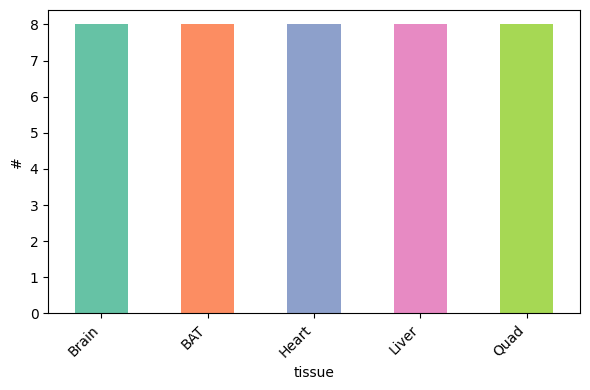

In [9]:
pr.pl.n_samples_per_category(
    adata, 
    category_key='tissue',
    order=tissue_order,
    color_scheme=adata.uns['colors_tissue'],
    )

We identify approximately 30,000 peptides and 3,800 proteins per sample.

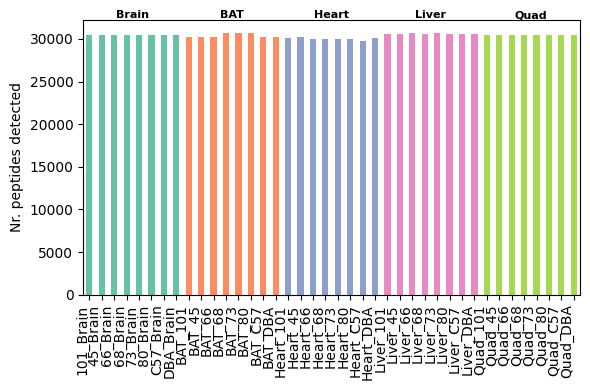

In [10]:
pr.pl.n_peptides_per_sample(
    adata,
    zero_to_na=True,
    order_by="tissue",
    order=tissue_order,
    color_scheme=adata.uns['colors_tissue'],
    )

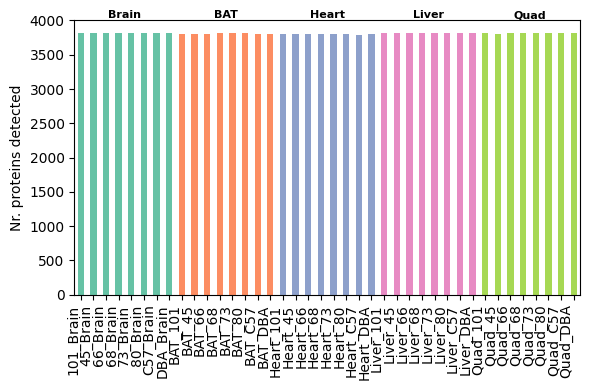

In [11]:
pr.pl.n_proteins_per_sample(
    adata,
    zero_to_na=True,
    order_by="tissue",
    order=tissue_order,
    color_scheme=adata.uns['colors_tissue'],
    )

In [12]:
# Reduce overlapping peptides resulting from missed cleavages to a single representative peptide
pr.pp.summarize_overlapping_peptides(adata)

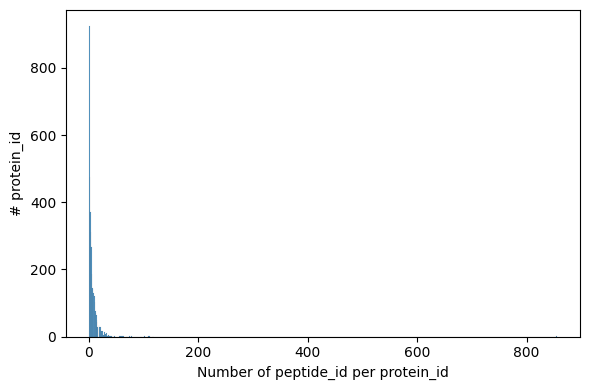

In [13]:
pr.pl.n_peptides_per_protein(adata)

In [14]:
# Protein A2ASS6 has an unusually high peptide count; remove as outlier
A2ASS6_mask = (adata.var['protein_id'] == 'A2ASS6')
print(f"N peptides for protein A2ASS6: {A2ASS6_mask.sum()}")

N peptides for protein A2ASS6: 855


In [15]:
adata = adata[:, ~A2ASS6_mask]

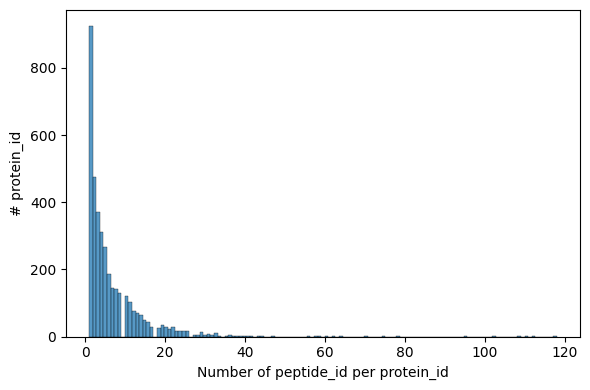

In [16]:
pr.pl.n_peptides_per_protein(adata)

## Exploratory analysis of peptides

Before proteoform inference, we verify data quality. Samples should cluster by tissue, with high intra-tissue and low inter-tissue correlation — a strong predisposition for tissue-specific proteoform detection by COPF.

### Sample correlation matrix

High intra-tissue correlation and lower inter-tissue correlation confirm replicate consistency and tissue-specific signal.

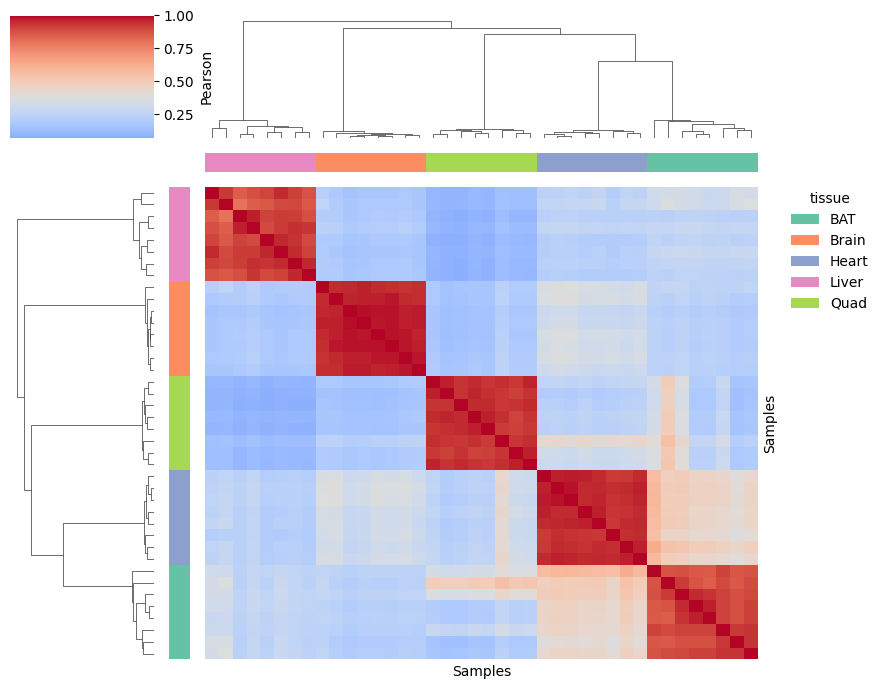

In [17]:
pr.pl.sample_correlation_matrix(
    adata,
    method="pearson",
    margin_color="tissue",
    color_scheme=adata.uns["colors_tissue"],
)

### PCA

Principal component analysis confirms that tissue identity is the dominant source of variance, with clear separation across the first four components. The mouse of origin does not drive the clustering.

/home/ifichtner/miniforge3/envs/proteopy-usage2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


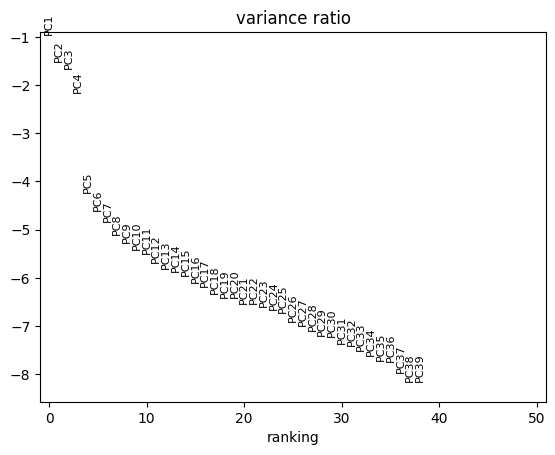

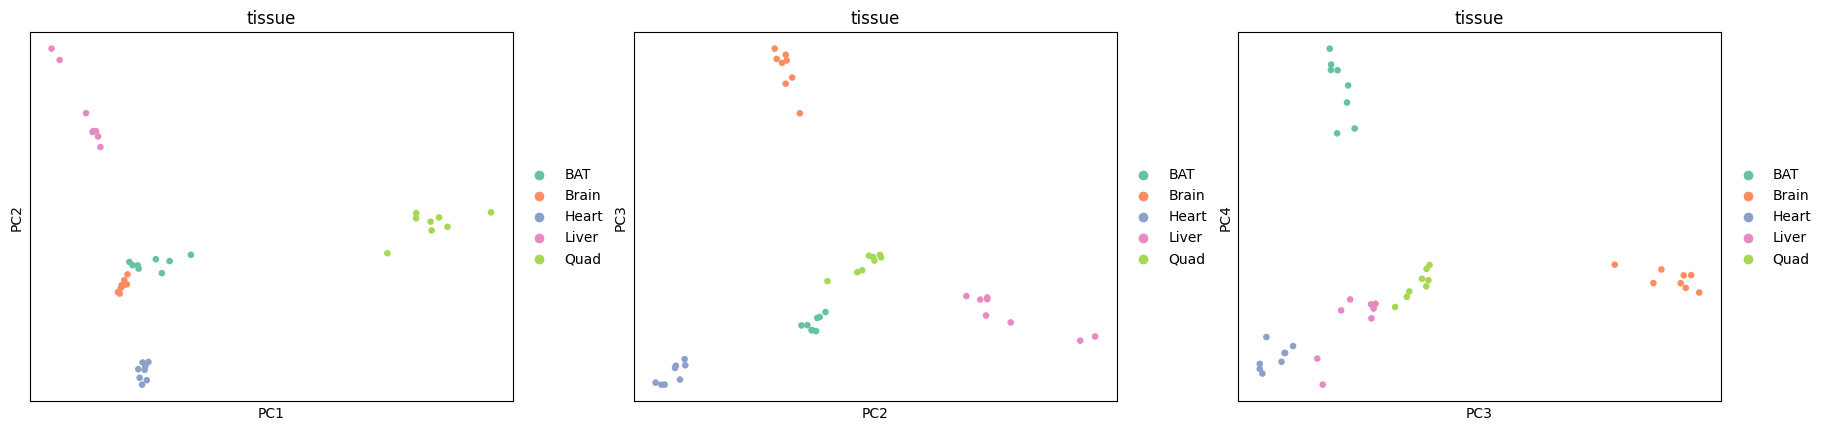

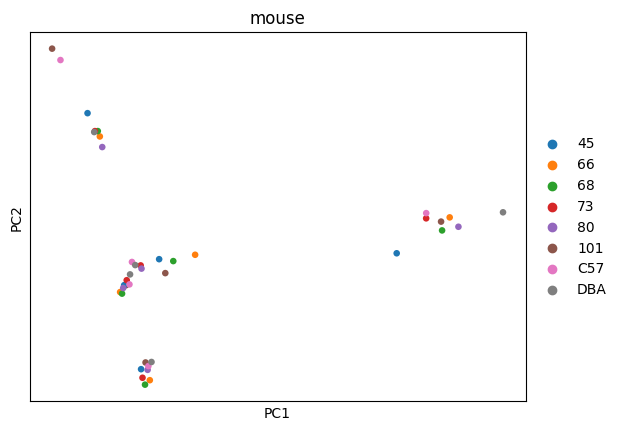

In [18]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=['tissue', 'tissue', 'tissue'],
    dimensions=[(0, 1), (1, 2), (2,3)],
    ncols=3,
    size=90,
    palette=adata.uns['colors_tissue'],
    )
sc.pl.pca(
    adata,
    color=['mouse'],
    dimensions=[(0, 1)],
    size=90,
    )


### UMAP

Non-linear dimensionality reduction clearly separates samples by tissue.

/home/ifichtner/miniforge3/envs/proteopy-usage2/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


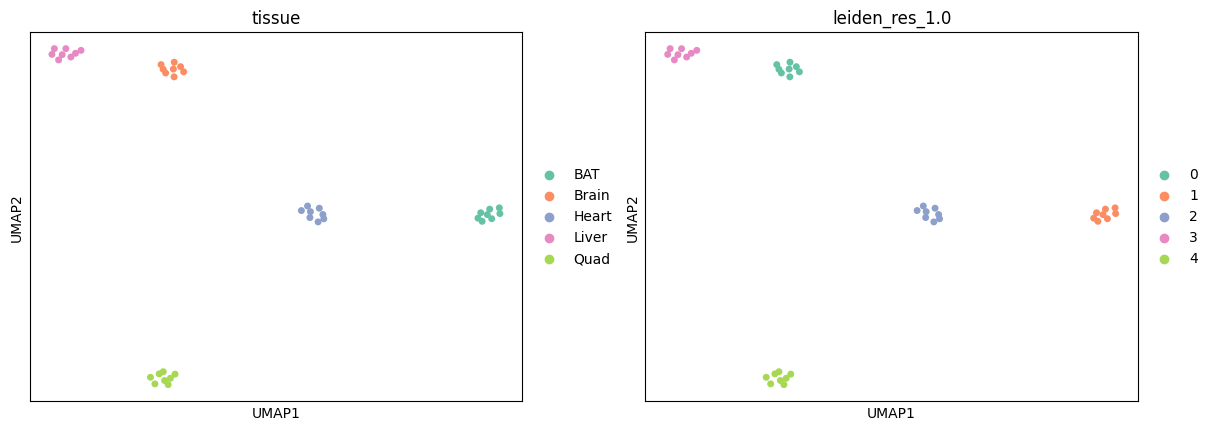

In [19]:
leiden_res = 1.0
leiden_key = f'leiden_res_{str(leiden_res)}'

sc.pp.neighbors(adata, n_neighbors=4)
sc.tl.leiden(
    adata,
    flavor='igraph',
    resolution=leiden_res,
    n_iterations=2,
    key_added=leiden_key,
    )
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=['tissue', leiden_key],
    size=100,
    palette=adata.uns['colors_tissue'],
    )

## Proteoform inference

We apply the COPF workflow: (1) compute pairwise peptide correlations within each protein, (2) perform hierarchical clustering on the correlation distance, (3) cut each dendrogram into two clusters, and (4) score the between- vs. within-cluster correlation difference. Proteins require at least 4 peptides for meaningful clustering.

In [20]:
# Require ≥4 peptides per protein for COPF analysis
pr.pp.filter_proteins_by_peptide_count(adata, min_count=4)
pr.pp.remove_zero_variance_vars(adata)

Removed 1770 proteins and 2984 peptides.
Removed 12 variables.


In [21]:
# COPF pipeline: correlate, cluster, score
pr.tl.pairwise_peptide_correlations(adata)
pr.tl.peptide_dendograms_by_correlation(adata, method='agglomerative-hierarchical-clustering')
pr.tl.peptide_clusters_from_dendograms(adata, n_clusters=2, min_peptides_per_cluster=2)
pr.tl.proteoform_scores(adata, min_score=0.1, min_pval_adj=0.1)

In [22]:
# Remove COPF outlier peptides (cluster_id == 1000000)
copf_outliers = (adata.var['cluster_id'] == 1000000)
adata = adata[:, ~copf_outliers]

### Proteoform scores (reproduces Figure 6B)

The pseudo-volcano plot shows proteoform scores vs. adjusted p-values. Bludau et al. reported 2,885 proteins and 63 proteins with significant proteoform groups at a score threshold of 0.1 and adjusted p-value threshold of 0.1. The two highlighted proteins — Ldb3 (Q9JKS4) and Sorbs2 (Q3UTJ2) — are examined in detail below.

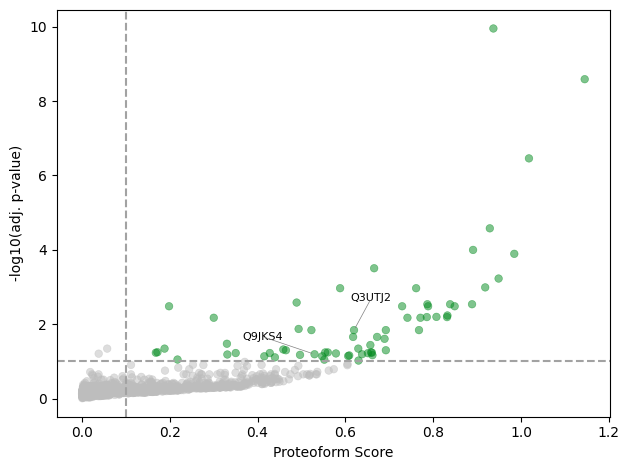

<Axes: xlabel='Proteoform Score', ylabel='-log10(adj. p-value)'>

In [23]:
bludauI_proteoforms = ['Q9JKS4', 'Q3UTJ2']
pr.pl.proteoform_scores(
    adata,
    adj=True,
    pval_threshold=0.1,
    score_threshold=0.1,
    log_scores=True,
    highlight_prots=bludauI_proteoforms
    )

In [24]:
pf_df = pr.get.proteoforms_df(adata, only_proteins=True)
n_proteoforms = pf_df[pf_df['is_proteoform'] == 1].shape[0]
print(f"{n_proteoforms} significant proteoforms inferred "
      f"(Bludau et al.: 63).")

64 significant proteoforms inferred (Bludau et al.: 63).


## Proteoform exploration

We examine two biologically validated proteoform examples from the publication: LIM domain-binding protein 3 (Ldb3, Q9JKS4) and Sorbin and SH3 domain-containing protein 2 (Sorbs2, Q3UTJ2).

### LIM domain-binding protein 3 — Ldb3 (Q9JKS4)

Ldb3 is a muscle-specific protein. COPF assigns its peptides to two tissue-specific proteoform groups, consistent with known alternative splice variants (reproduces Figure 7A).

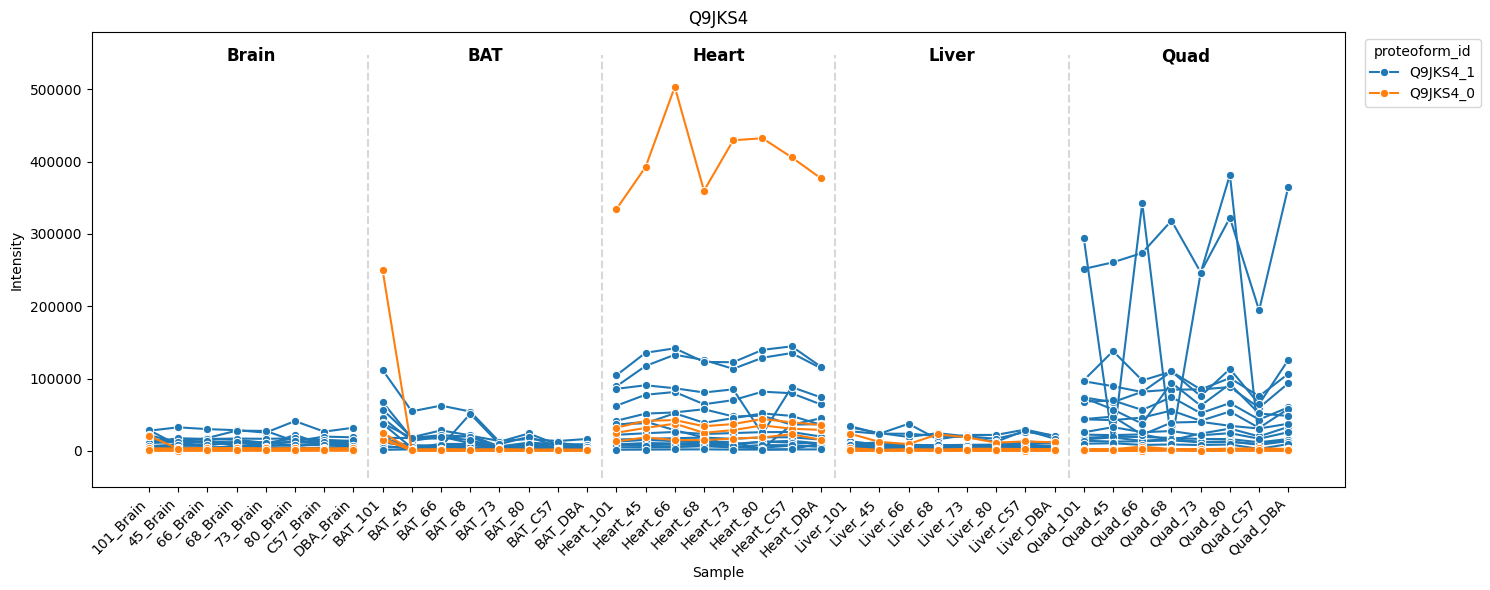

In [25]:
pr.pl.proteoform_intensities(
    adata,
    protein_ids="Q9JKS4",
    order_by='tissue',
    order=tissue_order,
    xlab_rotation=45,
    )

In [26]:
pr.get.proteoforms_df(adata, proteins="Q9JKS4")

,protein_id,peptide_id,cluster_id,proteoform_score,proteoform_score_pval,proteoform_score_pval_adj,is_proteoform
0,Q9JKS4,QYNNPIGLYSAETLR,0.0,0.529813,0.002771,0.064139,1.0
1,Q9JKS4,ASSEGAQGSVSPK,0.0,0.529813,0.002771,0.064139,1.0
2,Q9JKS4,VLPGPSQPR,0.0,0.529813,0.002771,0.064139,1.0
3,Q9JKS4,EMAQMYQMSLR,0.0,0.529813,0.002771,0.064139,1.0
4,Q9JKS4,ILAQMTGTEYMQDPDEEALRR,1.0,0.529813,0.002771,0.064139,1.0
5,Q9JKS4,IMGEVMHALR,1.0,0.529813,0.002771,0.064139,1.0
6,Q9JKS4,QTWHTTCFVCAACK,1.0,0.529813,0.002771,0.064139,1.0
7,Q9JKS4,SKRPIPISTTAPPIQSPLPVIPHQK,1.0,0.529813,0.002771,0.064139,1.0
8,Q9JKS4,SASYNLSLTLQK,1.0,0.529813,0.002771,0.064139,1.0
9,Q9JKS4,SWHPEEFNCAYCK,1.0,0.529813,0.002771,0.064139,1.0


### Ldb3 peptide sequence map (reproduces Figure 7C)

Mapping detected peptides onto the canonical protein sequence and annotated UniProt alternative sequences confirms that the two proteoform groups correspond to known splice variants.

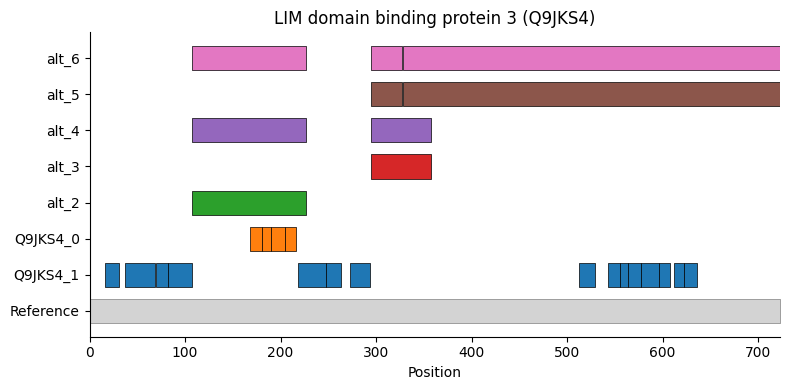

<Axes: title={'center': 'LIM domain binding protein 3 (Q9JKS4)'}, xlabel='Position'>

In [27]:
# Canonical sequence and UniProt alternative sequences for Q9JKS4
# Source: https://www.uniprot.org/uniprotkb/Q9JKS4/entry#sequences
seq = 'MSYSVTLTGPGPWGFRLQGGKDFNMPLTISRITPGSKAAQSQLSQGDLVVAIDGVNTDTMTHLEAQNKIKSASYNLSLTLQKSKRPIPISTTAPPIQSPLPVIPHQKDPALDTNGSLATPSPSPEARASPGALEFGDTFSSSFSQTSVCSPLMEASGPVLPLGSPVAKASSEGAQGSVSPKVLPGPSQPRQYNNPIGLYSAETLREMAQMYQMSLRGKASGAGLLGGSLPVKDLAVDSASPVYQAVIKTQSKPEDEADEWARRSSNLQSRSFRILAQMTGTEYMQDPDEEALRRSSTPIEHAPVCTSQATSPLLPASAQSPAAASPIAASPTLATAAATHAAAASAAGPAASPVENPRPQASAYSPAAAASPAPSAHTSYSEGPAAPAPKPRVVTTASIRPSVYQPVPASSYSPSPGANYSPTPYTPSPAPAYTPSPAPTYTPSPAPTYSPSPAPAYTPSPAPNYTPTPSAAYSGGPSESASRPPWVTDDSFSQKFAPGKSTTTVSKQTLPRGAPAYNPTGPQVTPLARGTFQRAERFPASSRTPLCGHCNNVIRGPFLVAMGRSWHPEEFNCAYCKTSLADVCFVEEQNNVYCERCYEQFFAPICAKCNTKIMGEVMHALRQTWHTTCFVCAACKKPFGNSLFHMEDGEPYCEKDYINLFSTKCHGCDFPVEAGDKFIEALGHTWHDTCFICAVCHVNLEGQPFYSKKDKPLCKKHAHAINV'
alt_seqs = {
    'Q9JKS4-2_0': {'seq_coord': (107, 227), 'group': 'alt_2'},
    'Q9JKS4-3_0': {'seq_coord': (295, 357), 'group': 'alt_3'},
    'Q9JKS4-4_0': {'seq_coord': (107, 227), 'group': 'alt_4'},
    'Q9JKS4-4_1': {'seq_coord': (295, 357), 'group': 'alt_4'},
    'Q9JKS4-5_0': {'seq_coord': (295, 327), 'group': 'alt_5'},
    'Q9JKS4-5_1': {'seq_coord': (328, 723), 'group': 'alt_5'},
    'Q9JKS4-6_0': {'seq_coord': (107, 227), 'group': 'alt_6'},
    'Q9JKS4-6_1': {'seq_coord': (295, 327), 'group': 'alt_6'},
    'Q9JKS4-6_2': {'seq_coord': (328, 723), 'group': 'alt_6'},
}

pr.pl.peptides_on_prot_sequence(
    adata,
    protein_id="Q9JKS4",
    group_by='proteoform_id',
    ref_sequence=seq,
    add_sequences=alt_seqs,
    title="LIM domain binding protein 3 (Q9JKS4)",
    figsize=(8, 4),
)

### Sorbin and SH3 domain-containing protein 2 — Sorbs2 (Q3UTJ2)

Sorbs2 peptides are assigned to two proteoform groups with distinct tissue expression patterns: one group is abundant across brain, heart, and liver, while the other is brain-specific (reproduces Figure 7D).

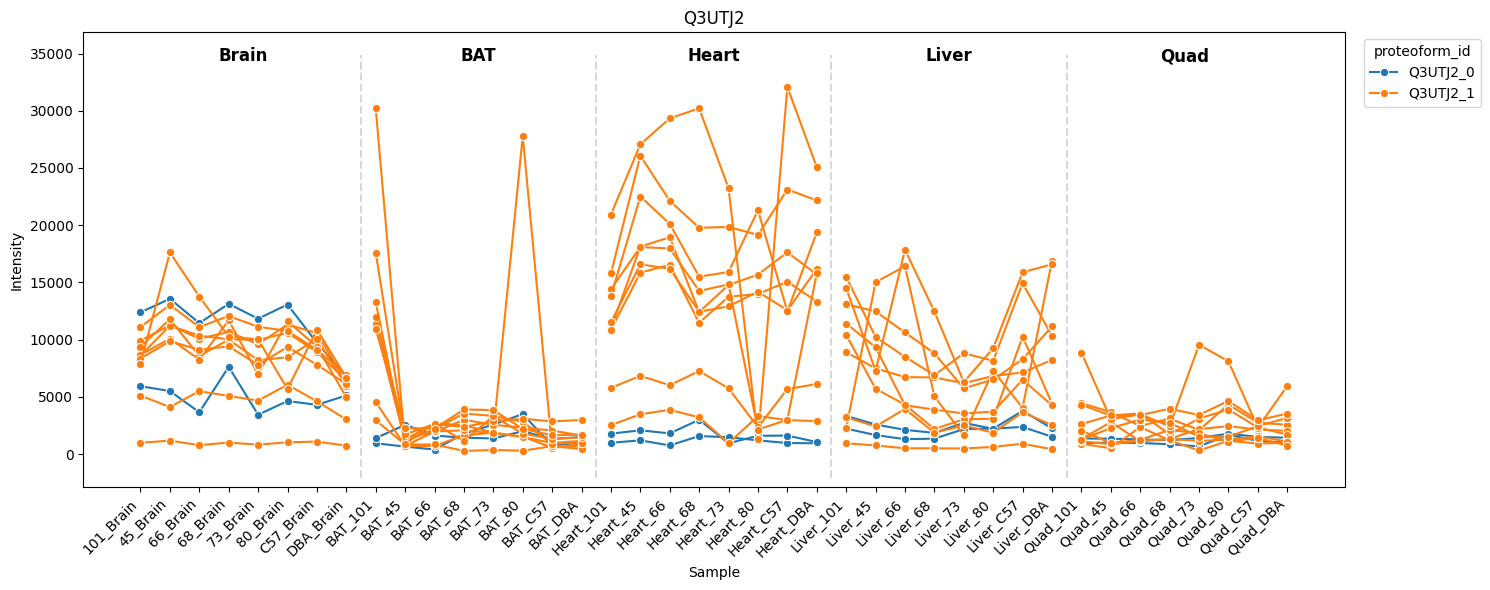

In [28]:
pr.pl.proteoform_intensities(
    adata,
    protein_ids="Q3UTJ2",
    order_by='tissue',
    order=tissue_order,
    xlab_rotation=45,
    )

In [29]:
pr.get.proteoforms_df(adata, proteins="Q3UTJ2")

,protein_id,peptide_id,cluster_id,proteoform_score,proteoform_score_pval,proteoform_score_pval_adj,is_proteoform
0,Q3UTJ2,LAFLVSPVPFR,0.0,0.619637,0.000343,0.014379,1.0
1,Q3UTJ2,ASVVEALDSALKDICDQIK,0.0,0.619637,0.000343,0.014379,1.0
2,Q3UTJ2,QGIFPVSYVEVVKR,1.0,0.619637,0.000343,0.014379,1.0
3,Q3UTJ2,APHYPGIGPVDESGIPTAIR,1.0,0.619637,0.000343,0.014379,1.0
4,Q3UTJ2,SFISSSPSSPSR,1.0,0.619637,0.000343,0.014379,1.0
5,Q3UTJ2,SIFEYEPGK,1.0,0.619637,0.000343,0.014379,1.0
6,Q3UTJ2,AQPARPPPPVQPGEIGEAIAK,1.0,0.619637,0.000343,0.014379,1.0
7,Q3UTJ2,SYSSTLTDLGR,1.0,0.619637,0.000343,0.014379,1.0
8,Q3UTJ2,VGIFPISYVEK,1.0,0.619637,0.000343,0.014379,1.0
9,Q3UTJ2,ADLPGSSSTFTK,1.0,0.619637,0.000343,0.014379,1.0


### Sorbs2 peptide sequence map (reproduces Figure 7F)

The brain-specific proteoform group maps to a region covered by alternative sequences 3, 4 and 5 in UniProt (10 in Bludau et. al. Figure 7F), a brain-specific splice variant.

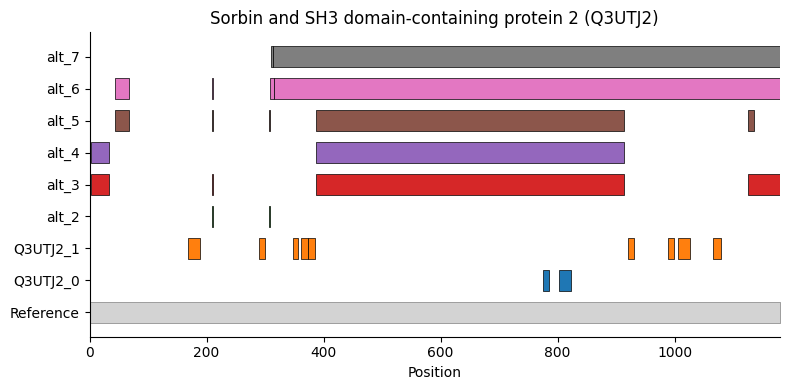

<Axes: title={'center': 'Sorbin and SH3 domain-containing protein 2 (Q3UTJ2)'}, xlabel='Position'>

In [30]:
# Canonical sequence and UniProt alternative sequences for Q3UTJ2
# Source: https://www.uniprot.org/uniprotkb/Q3UTJ2/entry#sequences
seq = 'MNTDSGGCARKRAAMSVTLTSVKRVQSSPNLLAAGRESQSPDSAWRSYNDRNPETLNGDATYSSLAAKGFRSVRPNLQDKRSPTQSQITINGNSGGAVSPVSYYQRPFSPSAYSLPASLNSSIIMQHGRSLDSAETYSQHAQSLDGTMGSSIPLYRSSEEEKRVTVIKAPHYPGIGPVDESGIPTAIRTTVDRPKDWYKTMFKQIHMVHKPGLYNSPYSAQSHPAAKTQTYRPLSKSHSDNGTDAFKEVPSPVPPPHVPPRPRDQSSTLKHDWDPPDRKVDTRKFRSEPRSIFEYEPGKSSILQHERPVSIYQSSIDRSLERPSSSASMAGDFRKRRKSEPAVGPLRGLGDQSSSRTSPGRADLPGSSSTFTKSFISSSPSSPSRAQGGDDSKMCPPLCSYSGLNGTPSGELECCNAYRQHLDVPGDSQRAITFKNGWQMARQNAEIWSSTEETVSPKIKSRSCDDLLNDDCDSFPDPKTKSESMGSLLCEEDSKESCPMTWASPYIQEVCGNSRSRLKHRSAHNAPGFLKMYKKMHRINRKDLMNSEVICSVKSRILQYEKEQQHRGLLHGWSQSSTEEVPRDVVPTRISEFEKLIQKSKSMPNLGDEMLSPITLEPPQNGLCPKRRFSIESLLEEETQVRHPSQGQRSCKSNTLVPIHIEVTSDEQPRTHMEFSDSDQDGVVSDHSDYVHVEGSSFCSESDFDHFSFTSSESFYGSSHHHHHHHHHHRHLISSCKGRCPASYTRFTTMLKHERAKHENMDRPRRQEMDPGLSKLAFLVSPVPFRRKKILTPQKQTEKAKCKASVVEALDSALKDICDQIKAEKRRGSLPDNSILHRLISELLPQIPERNSSLHALKRSPMHQPFHPLPPDGASHCPLYQNDCGRMPHSASFPDVDTTSNYHAQDYGSALSLQDHESPRSYSSTLTDLGRSASRERRGTPEKEKLPAKAVYDFKAQTSKELSFKKGDTVYILRKIDQNWYEGEHHGRVGIFPISYVEKLTPPEKAQPARPPPPVQPGEIGEAIAKYNFNADTNVELSLRKGDRIILLKRVDQNWYEGKIPGTNRQGIFPVSYVEVVKRNAKGAEDYPDPPLPHSYSSDRIYTLSSNKPQRPGFSHENIQGGGEPFQALYNYTPRNEDELELRESDVVDVMEKCDDGWFVGTSRRTKFFGTFPGNYVKRL'
alt_seqs = {
    'Q3UTJ2-2_0': {'seq_coord': (210, 211), 'group': 'alt_2'},
    'Q3UTJ2-2_1': {'seq_coord': (307, 308), 'group': 'alt_2'},
    'Q3UTJ2-3_0': {'seq_coord': (3, 34), 'group': 'alt_3'},
    'Q3UTJ2-3_1': {'seq_coord': (210, 211), 'group': 'alt_3'},
    'Q3UTJ2-3_2': {'seq_coord': (387, 914), 'group': 'alt_3'},
    'Q3UTJ2-3_3': {'seq_coord': (1125, 1180), 'group': 'alt_3'},
    'Q3UTJ2-4_0': {'seq_coord': (3, 34), 'group': 'alt_4'},
    'Q3UTJ2-4_1': {'seq_coord': (387, 914), 'group': 'alt_4'},
    'Q3UTJ2-5_0': {'seq_coord': (44, 67), 'group': 'alt_5'},
    'Q3UTJ2-5_1': {'seq_coord': (210, 211), 'group': 'alt_5'},
    'Q3UTJ2-5_2': {'seq_coord': (307, 308), 'group': 'alt_5'},
    'Q3UTJ2-5_3': {'seq_coord': (387, 914), 'group': 'alt_5'},
    'Q3UTJ2-5_4': {'seq_coord': (1125, 1135), 'group': 'alt_5'},
    'Q3UTJ2-6_0': {'seq_coord': (44, 67), 'group': 'alt_6'},
    'Q3UTJ2-6_1': {'seq_coord': (210, 211), 'group': 'alt_6'},
    'Q3UTJ2-6_2': {'seq_coord': (308, 316), 'group': 'alt_6'},
    'Q3UTJ2-6_3': {'seq_coord': (316, 1180), 'group': 'alt_6'},
    'Q3UTJ2-7_0': {'seq_coord': (310, 313), 'group': 'alt_7'},
    'Q3UTJ2-7_1': {'seq_coord': (313, 1180), 'group': 'alt_7'},
}

pr.pl.peptides_on_prot_sequence(
    adata,
    protein_id="Q3UTJ2",
    group_by='proteoform_id',
    ref_sequence=seq,
    add_sequences=alt_seqs,
    title="Sorbin and SH3 domain-containing protein 2 (Q3UTJ2)",
    figsize=(8, 4),
)

## Proteoform quantification and statistical analysis

To identify tissue-specific proteoforms, we quantify proteoform-level intensities and apply one-way ANOVA across tissues. Bludau et al. reported that 56 of 63 proteoform-containing proteins (89%) were tissue-specific (Bonferroni-corrected p-value ≤ 0.01).

In [31]:
# Aggregate peptide intensities to proteoform level
adata_pfs = adata.copy()

pr.pp.quantify_proteoforms(
    adata_pfs,
    group_by="proteoform_id",
)

In [32]:
# Retain only significant proteoforms (score ≥ 0.1, adj. p-value ≤ 0.1)
pf_mask = (
    (adata_pfs.var['proteoform_score'].astype(float) >= 0.1)
    & (adata_pfs.var['proteoform_score_pval_adj'].astype(float) <= 0.1)
)
adata_pfs = adata_pfs[:, pf_mask].copy()

In [33]:
# Log2 transform for statistical testing
adata_pfs.layers['raw'] = adata_pfs.X
adata_pfs.X[adata_pfs.X == 0] = np.nan
adata_pfs.X = np.log2(adata_pfs.X)
adata_pfs.X[np.isnan(adata_pfs.X)] = 0

In [34]:
# One-way ANOVA across tissues
pr.tl.differential_abundance(
    adata_pfs,
    method='anova_oneway',
    multitest_correction='bonferroni',
    group_by='tissue',
    alpha=0.01,
    space='log',
)

Saved test results in .varm['anova_oneway;tissue;all']


In [35]:
anova_results = pr.get.differential_abundance_df(adata_pfs, keys='anova_oneway;tissue;all')
anova_results.rename(columns={'var_id': 'proteoform_id'}, inplace=True)
anova_results

,proteoform_id,test_type,group_by,design,fstat,pval,mean_Brain,mean_BAT,mean_Heart,mean_Liver,mean_Quad,pval_adj,is_diff_abundant
0,O08601_0,anova_oneway,tissue,all,29.998692,7.135979e-11,15.447875,16.438822,13.642355,15.286296,13.226680,9.134053e-09,True
1,O08601_1,anova_oneway,tissue,all,309.316738,8.846917e-27,17.173194,16.274997,16.297549,19.401295,16.539176,1.132405e-24,True
2,O54724_0,anova_oneway,tissue,all,12.603239,1.878084e-06,15.879478,13.639894,8.489357,10.545068,11.828292,2.403947e-04,True
3,O54724_1,anova_oneway,tissue,all,184.250825,5.444913e-23,16.359031,19.356209,18.207868,15.845380,17.226098,6.969489e-21,True
4,O54749_0,anova_oneway,tissue,all,5.288221,1.938883e-03,13.162980,12.879554,14.428646,13.568651,13.071253,2.481771e-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Q9JKS4_1,anova_oneway,tissue,all,66.936903,6.594055e-16,17.255804,17.226273,19.196674,17.040296,19.944539,8.440390e-14,True
124,Q9QYR6_0,anova_oneway,tissue,all,14.856602,3.441306e-07,15.506743,12.560879,13.676294,13.230452,13.061866,4.404872e-05,True
125,Q9QYR6_1,anova_oneway,tissue,all,646.764070,2.861598e-32,20.504493,16.481401,16.861090,17.344528,16.848407,3.662846e-30,True
126,Q9Z204_0,anova_oneway,tissue,all,75.275766,1.071660e-16,16.117296,12.403909,12.737527,13.374945,12.716591,1.371725e-14,True


In [36]:
# Count proteins with all proteoforms being significantly tissue-specific 
protein_id_map = (
    adata_pfs.var[['protein_id', 'protein_id_old']]
    .set_index('protein_id')['protein_id_old']
)
anova_results['protein_id'] = (anova_results['proteoform_id'].map(protein_id_map))
n_tissue_specific_pfs = anova_results.groupby('protein_id')['is_diff_abundant'].all().sum()

print(
    f"{n_tissue_specific_pfs} tissue-specific proteoforms "
    f"found via ANOVA (Bludau et al.: 56)."
)

58 tissue-specific proteoforms found via ANOVA (Bludau et al.: 56).


## Summary

This tutorial reproduced the core proteoform inference workflow from Bludau et al. (2021) using ProteoPy. Key results:

- **Proteoform detection**: COPF identified a comparable number of significant proteoform groups to the 63 reported in the original study (Figure 6B).
- **Biological validation**: The tissue-specific proteoform assignments for Ldb3 (Q9JKS4) and Sorbs2 (Q3UTJ2) match the published findings (Figures 7A, 7C, 7D, 7F), with peptide-to-sequence mappings consistent with known alternative splice variants.
- **Tissue specificity**: ANOVA analysis recovered a similar proportion of tissue-specific proteoforms to the 56 (89%) reported by Bludau et al.

Minor numerical differences are expected due to implementation details in preprocessing (e.g., peptide modification summarization, overlapping peptide handling) and statistical testing.

In [37]:
!pip freeze

adjustText==1.3.0
anndata==0.11.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.13.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.2.0
attrs==25.4.0
babel==2.18.0
beautifulsoup4==4.14.3
biopython==1.86
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
comm==0.2.3
contourpy==1.3.2
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
et_xmlfile==2.0.0
exceptiongroup==1.3.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
h11==0.16.0
h5py==3.15.1
httpcore==1.0.9
httpx==0.28.1
idna==3.11
igraph==1.0.0
ipykernel==7.2.0
ipython==8.38.0
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.4
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
kiwisolver==1.4.